In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df =pd.read_excel("../data/dataset.xlsx")

In [4]:
print(df.head())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826     False   


In [5]:
print(df.shape)

(114000, 21)


In [6]:
print(df.columns)

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113951 non-null  object 
 3   album_name        113988 non-null  object 
 4   track_name        113990 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [8]:
df.isnull().sum()

Unnamed: 0           0
track_id             0
artists             49
album_name          12
track_name          10
popularity           0
duration_ms          0
explicit             0
danceability         0
energy               0
key                  0
loudness             0
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo                0
time_signature       0
track_genre          0
dtype: int64

In [9]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


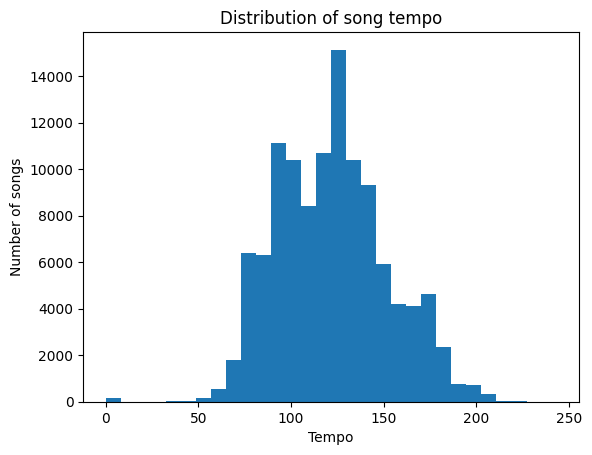

In [10]:
plt.hist(df["tempo"], bins=30)

plt.title("Distribution of song tempo")
plt.xlabel("Tempo")
plt.ylabel("Number of songs")

plt.show()

In [11]:
duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [12]:
df = df.dropna()

print(df.shape)

(113940, 21)


In [13]:
print(df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [14]:
def assign_mood(genre):
    genre = str(genre).lower()

    calm_keywords = [
        "acoustic", "ambient", "chill", "classical", "jazz",
        "piano", "sleep", "study", "instrumental", "new-age",
        "opera", "orchestra", "meditation", "relax", "lo-fi",
        "lounge", "soft", "singer-songwriter", "folk"
    ]

    energetic_keywords = [
        "rock", "metal", "punk", "hardcore", "edm", "house",
        "techno", "trance", "dubstep", "drum-and-bass",
        "hip-hop", "rap", "trap", "dance", "electro",
        "electronic", "garage", "grime", "power", "speed"
    ]

    neutral_keywords = [
        "pop", "indie", "alternative", "r&b", "soul",
        "funk", "country", "blues", "latin", "reggae",
        "ska", "disco", "afro", "world", "gospel",
        "k-pop", "j-pop", "britpop", "movie", "soundtrack"
    ]

    for keyword in calm_keywords:
        if keyword in genre:
            return "Calm"

    for keyword in energetic_keywords:
        if keyword in genre:
            return "Energetic"

    for keyword in neutral_keywords:
        if keyword in genre:
            return "Neutral"

    return np.nan

In [15]:
df["mood"] = df["track_genre"].apply(assign_mood)

In [16]:
df = df.dropna(subset=["mood"])

In [17]:
print(df["mood"].value_counts())

mood
Energetic    33988
Neutral      22995
Calm         12000
Name: count, dtype: int64


In [18]:
print(df[["track_genre", "mood"]].sample(20))

           track_genre       mood
88139           reggae    Neutral
38327           garage  Energetic
72434        metalcore  Energetic
107215       synth-pop    Neutral
113495     world-music    Neutral
64572             jazz       Calm
73315   minimal-techno  Energetic
24346   detroit-techno  Energetic
88866           reggae    Neutral
70824         mandopop    Neutral
105169           study       Calm
30992              edm  Energetic
63622           j-rock  Energetic
64832             jazz       Calm
84353       psych-rock  Energetic
81100              pop    Neutral
109122          techno  Energetic
110599          trance  Energetic
15317            chill       Calm
48814         hardcore  Energetic


In [19]:
features = ["danceability","energy","acousticness","loudness","tempo","valence"
]

In [20]:
X = df[features]

In [21]:
print(X.head())

   danceability  energy  acousticness  loudness    tempo  valence
0         0.676  0.4610        0.0322    -6.746   87.917    0.715
1         0.420  0.1660        0.9240   -17.235   77.489    0.267
2         0.438  0.3590        0.2100    -9.734   76.332    0.120
3         0.266  0.0596        0.9050   -18.515  181.740    0.143
4         0.618  0.4430        0.4690    -9.681  119.949    0.167


In [22]:
print(X.shape)

(68983, 6)


In [23]:
label_mapping = {"Calm": 0, "Energetic": 1, "Neutral": 2}

In [24]:
y = []

for mood in df["mood"]: y.append(label_mapping[mood])

In [25]:
y = np.array(y)

In [26]:
random_indices = np.random.choice(len(y), size=20, replace=False)

print(y[random_indices])

[2 0 0 1 1 1 2 1 0 2 1 1 1 0 2 1 2 2 2 0]


In [27]:
print(label_mapping)

{'Calm': 0, 'Energetic': 1, 'Neutral': 2}


In [28]:
print(len(y))
print(len(X))

68983
68983


In [29]:
indices = np.arange(len(X))

print(indices[:10])

[0 1 2 3 4 5 6 7 8 9]


In [30]:
np.random.seed(42)

np.random.shuffle(indices)

In [31]:
print(indices[:20])

[62765 41067 24979 40421 32211 40340 54375 14127 48304 56211 12928 68086
 66773  2975 37759 49635 31151 35259 31561 52187]


In [32]:
X = X.iloc[indices]

y = y[indices]

In [33]:
X = X.reset_index(drop=True)

In [34]:
print(X.head())
print(y[:10])

check_df = X.copy()
check_df["label"] = y
print(check_df.head(10))

   danceability  energy  acousticness  loudness    tempo  valence
0         0.155   0.993        0.0911   -16.381  133.085  0.00001
1         0.426   0.487        0.7850    -5.276  135.103  0.28000
2         0.662   0.477        0.7090    -7.218  173.942  0.44900
3         0.705   0.874        0.1700    -2.514  128.020  0.78800
4         0.655   0.716        0.4760    -5.077   80.813  0.52100
[0 2 2 2 2 2 1 1 2 2]
   danceability  energy  acousticness  loudness    tempo  valence  label
0         0.155   0.993      0.091100   -16.381  133.085  0.00001      0
1         0.426   0.487      0.785000    -5.276  135.103  0.28000      2
2         0.662   0.477      0.709000    -7.218  173.942  0.44900      2
3         0.705   0.874      0.170000    -2.514  128.020  0.78800      2
4         0.655   0.716      0.476000    -5.077   80.813  0.52100      2
5         0.548   0.704      0.016800    -4.838  104.666  0.28800      2
6         0.544   0.910      0.001570    -2.461  130.088  0.75600      

In [36]:
split = int(len(X) * 0.8)
print("split index:", split)

split index: 55186


In [38]:
X_train = X.iloc[:split]
X_test = X.iloc[split:]

In [40]:
y_train = y[:split]
y_test = y[split:]

In [44]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (55186, 6)
y_train: (55186,)
X_test: (13797, 6)
y_test: (13797,)


In [45]:
print("training:")
print(np.bincount(y_train))
print("testing:")
print(np.bincount(y_test))

training:
[ 9569 27269 18348]
testing:
[2431 6719 4647]


In [47]:
train_mean = X_train.mean()
print(train_mean)

danceability      0.567369
energy            0.646998
acousticness      0.279723
loudness         -8.161336
tempo           121.729948
valence           0.465559
dtype: float64


In [49]:
train_std = X_train.std()
print(train_std)

danceability     0.177666
energy           0.249867
acousticness     0.323830
loudness         5.223484
tempo           29.926394
valence          0.257071
dtype: float64


In [50]:
X_train = (X_train - train_mean) / train_std

In [51]:
X_test = (X_test - train_mean) / train_std

In [54]:
print(X_train.head())
print(X_train.mean())
print(X_train.std())

   danceability    energy  acousticness  loudness     tempo   valence
0     -2.321031  1.384741     -0.582478 -1.573598  0.379433 -1.810978
1     -0.795698 -0.640333      1.560316  0.552378  0.446865 -0.721822
2      0.532636 -0.680354      1.325625  0.180595  1.744682 -0.064415
3      0.774662  0.908488     -0.338831  1.081143  0.210184  1.254289
4      0.493236  0.276153      0.606111  0.590475 -1.367253  0.215664
danceability    1.457497e-16
energy          8.600778e-17
acousticness    1.108573e-16
loudness       -3.012847e-17
tempo           3.373359e-17
valence         2.157920e-16
dtype: float64
danceability    1.0
energy          1.0
acousticness    1.0
loudness        1.0
tempo           1.0
valence         1.0
dtype: float64


In [56]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()

In [ ]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=100):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def initialize_weights(self, n_features):
        np.random.seed(42)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0

    def linear_output(self, X):
        return np.dot(X, self.weights) + self.bias

    def activation(self, z):
        return np.where(z >= 0, 1, 0)
    
    def fit(self, X, y):
        self.initialize_weights(X.shape[1])
        for epoch in range(self.epochs):
            for x_i, target in zip(X, y):
                pass
                